# Exercicio 2 - Convolucao 2D e Filtragem

Este notebook implementa a convolucao 2D manualmente usando laços de repeticao.
A imagem escolhida para o exercicio e `tui.png`, salva na pasta compartilhada `../media` junto dos arquivos de audio.


In [ ]:
from __future__ import annotations

from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def find_asset(filename: str) -> Path:
    """Localiza um arquivo procurando a partir do diretorio atual e do projeto."""
    current = Path.cwd().resolve()
    candidates = []

    for base in (current, *current.parents):
        candidates.append(base / "media" / filename)
        candidates.append(base / "src" / "notebooks" / "DSP" / "media" / filename)
        candidates.append(base / filename)

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)

        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Nao foi possivel localizar {filename!r}.")


def load_grayscale_image(image_path: Path, max_size: int = 192) -> np.ndarray:
    """Carrega a imagem em tons de cinza e reduz o tamanho para acelerar a convolucao manual"""
    image = Image.open(image_path).convert("L")
    image.thumbnail((max_size, max_size))
    return np.asarray(image) / 255.0


def normalize_for_display(image: np.ndarray) -> np.ndarray:
    """Normaliza a imagem para o intervalo [0, 1] apenas para visualizacao."""
    image = image.astype(np.float32)
    image = image - image.min()
    max_value = image.max()
    if max_value > 0:
        image = image / max_value
    return image


def convolve2d_manual(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Aplica convolucao 2D manual usando padding e laços de repeticao."""
    kernel = np.asarray(kernel)
    kernel_flipped = np.flipud(np.fliplr(kernel))

    kernel_height, kernel_width = kernel_flipped.shape
    pad_y = kernel_height // 2
    pad_x = kernel_width // 2

    padded_image = np.pad(
        image,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode="constant",
    )

    output = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            region = padded_image[y : y + kernel_height, x : x + kernel_width]
            output[y, x] = np.sum(region * kernel_flipped)

    return output


def mean_kernel(size: int) -> np.ndarray:
    """Cria um kernel de media normalizado."""
    return np.ones((size, size)) / (size * size)


def gaussian_kernel(size: int) -> np.ndarray:
    """Cria um kernel gaussiano 2D normalizado."""
    axis = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(axis, axis)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * 0.8 **2))
    kernel = kernel / kernel.sum()
    return kernel.astype()


def gradient_magnitude(gx: np.ndarray, gy: np.ndarray) -> np.ndarray:
    """Combina as componentes horizontal e vertical da derivada p/ sobel e roberts que usa calculo da resposta no filtro 
    na direção X e na Y tbm."""
    return np.sqrt(gx**2 + gy**2)


def plot_images_grid(items: list[tuple[str, np.ndarray]], ncols: int = 2, cmap: str = "gray") -> None:
    """Plota uma lista de imagens em grade."""
    nrows = math.ceil(len(items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (title, image) in zip(axes, items):
        ax.imshow(normalize_for_display(image), cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


IMAGE_PATH = find_asset("tui.png")
image = load_grayscale_image(IMAGE_PATH)

print(f"Imagem usada: {IMAGE_PATH}")
print(f"Shape apos redimensionamento para acelerar a convolucao: {image.shape}")


Imagem usada: C:\Users\gabri\Desktop\DSP\DSPCodes\src\notebooks\DSP\media\tui.png
Shape apos redimensionamento para acelerar a convolucao manual: (192, 140)


## 2.a) Convolucao 2D com kernel de media e gaussiano

A seguir, a imagem `tui.png` e filtrada com kernels 3x3, 5x5 e 7x7.
Foi usada uma versao reduzida da imagem para que a convolucao manual com laços de repeticao nao fique lenta demais.


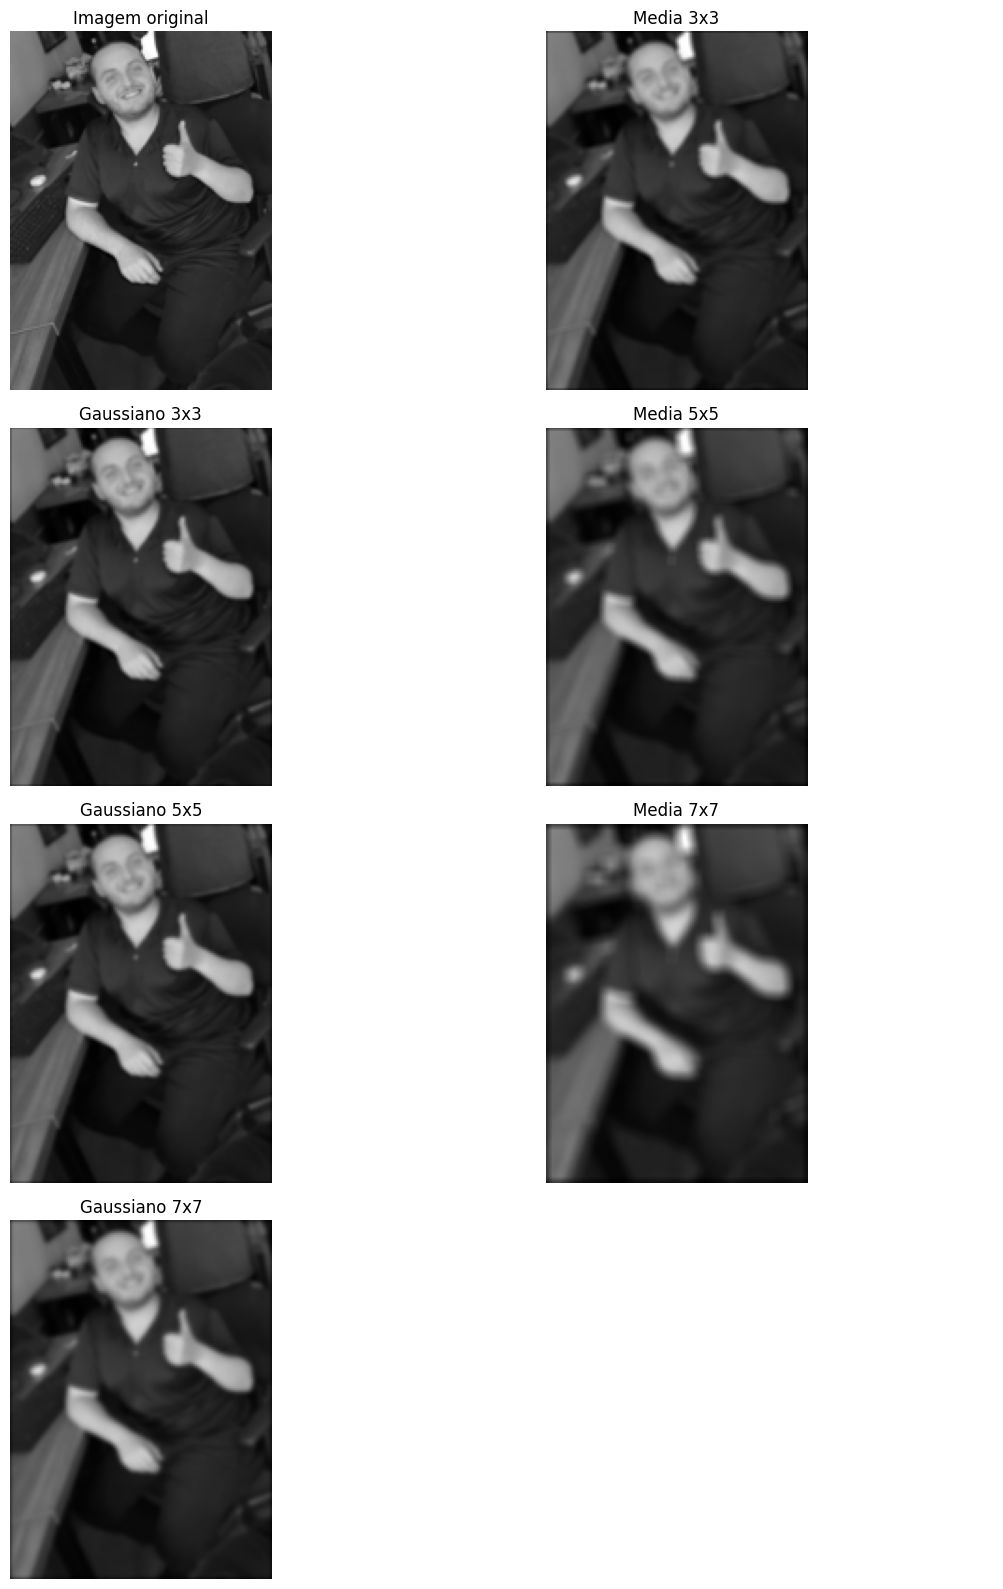

Kernel de media 3x3:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Kernel gaussiano 3x3:
[[0.0571 0.1248 0.0571]
 [0.1248 0.2725 0.1248]
 [0.0571 0.1248 0.0571]]
------------------------------------------------------------
Kernel de media 5x5:
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]

Kernel gaussiano 5x5:
[[0.0007 0.0063 0.0129 0.0063 0.0007]
 [0.0063 0.0545 0.1119 0.0545 0.0063]
 [0.0129 0.1119 0.2299 0.1119 0.0129]
 [0.0063 0.0545 0.1119 0.0545 0.0063]
 [0.0007 0.0063 0.0129 0.0063 0.0007]]
------------------------------------------------------------
Kernel de media 7x7:
[[0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040

In [ ]:
kernel_sizes = [3, 5, 7]
mean_results = {}
gaussian_results = {}

for size in kernel_sizes:
    mean_results[size] = convolve2d_manual(image, mean_kernel(size))
    gaussian_results[size] = convolve2d_manual(image, gaussian_kernel(size))

items = [("Imagem original", image)]
for size in kernel_sizes:
    items.append((f"Media {size}x{size}", mean_results[size]))
    items.append((f"Gaussiano {size}x{size}", gaussian_results[size]))

plot_images_grid(items, ncols=2)

for size in kernel_sizes:
    print(f"Kernel de media {size}x{size}:")
    print(mean_kernel(size))
    print()
    print(f"Kernel gaussiano {size}x{size}:")
    print(np.round(gaussian_kernel(size)))
    print("-" * 60)


### O que ocorre ao alterar o tamanho do kernel?

- **Media 3x3**: suaviza levemente a imagem e reduz pequenas variacoes locais.
- **Media 5x5**: aumenta o borramento e remove mais detalhes finos.
- **Media 7x7**: deixa a imagem ainda mais suave, mas perde muita nitidez.
- **Gaussiano 3x3**: suaviza como o kernel de media, mas preserva um pouco melhor as estruturas centrais.
- **Gaussiano 5x5**: aumenta a suavizacao sem espalhar tanto quanto a media simples.
- **Gaussiano 7x7**: gera um borramento mais forte, porem com transicoes visuais mais naturais que a media uniforme.

Em geral, quanto maior o kernel, maior a suavizacao e menor a quantidade de detalhes de alta frequencia preservados.


## 2.b) Convolucao 2D com Sobel, Roberts e Laplaciano

Agora sao aplicados os kernels de deteccao de borda pedidos no enunciado.


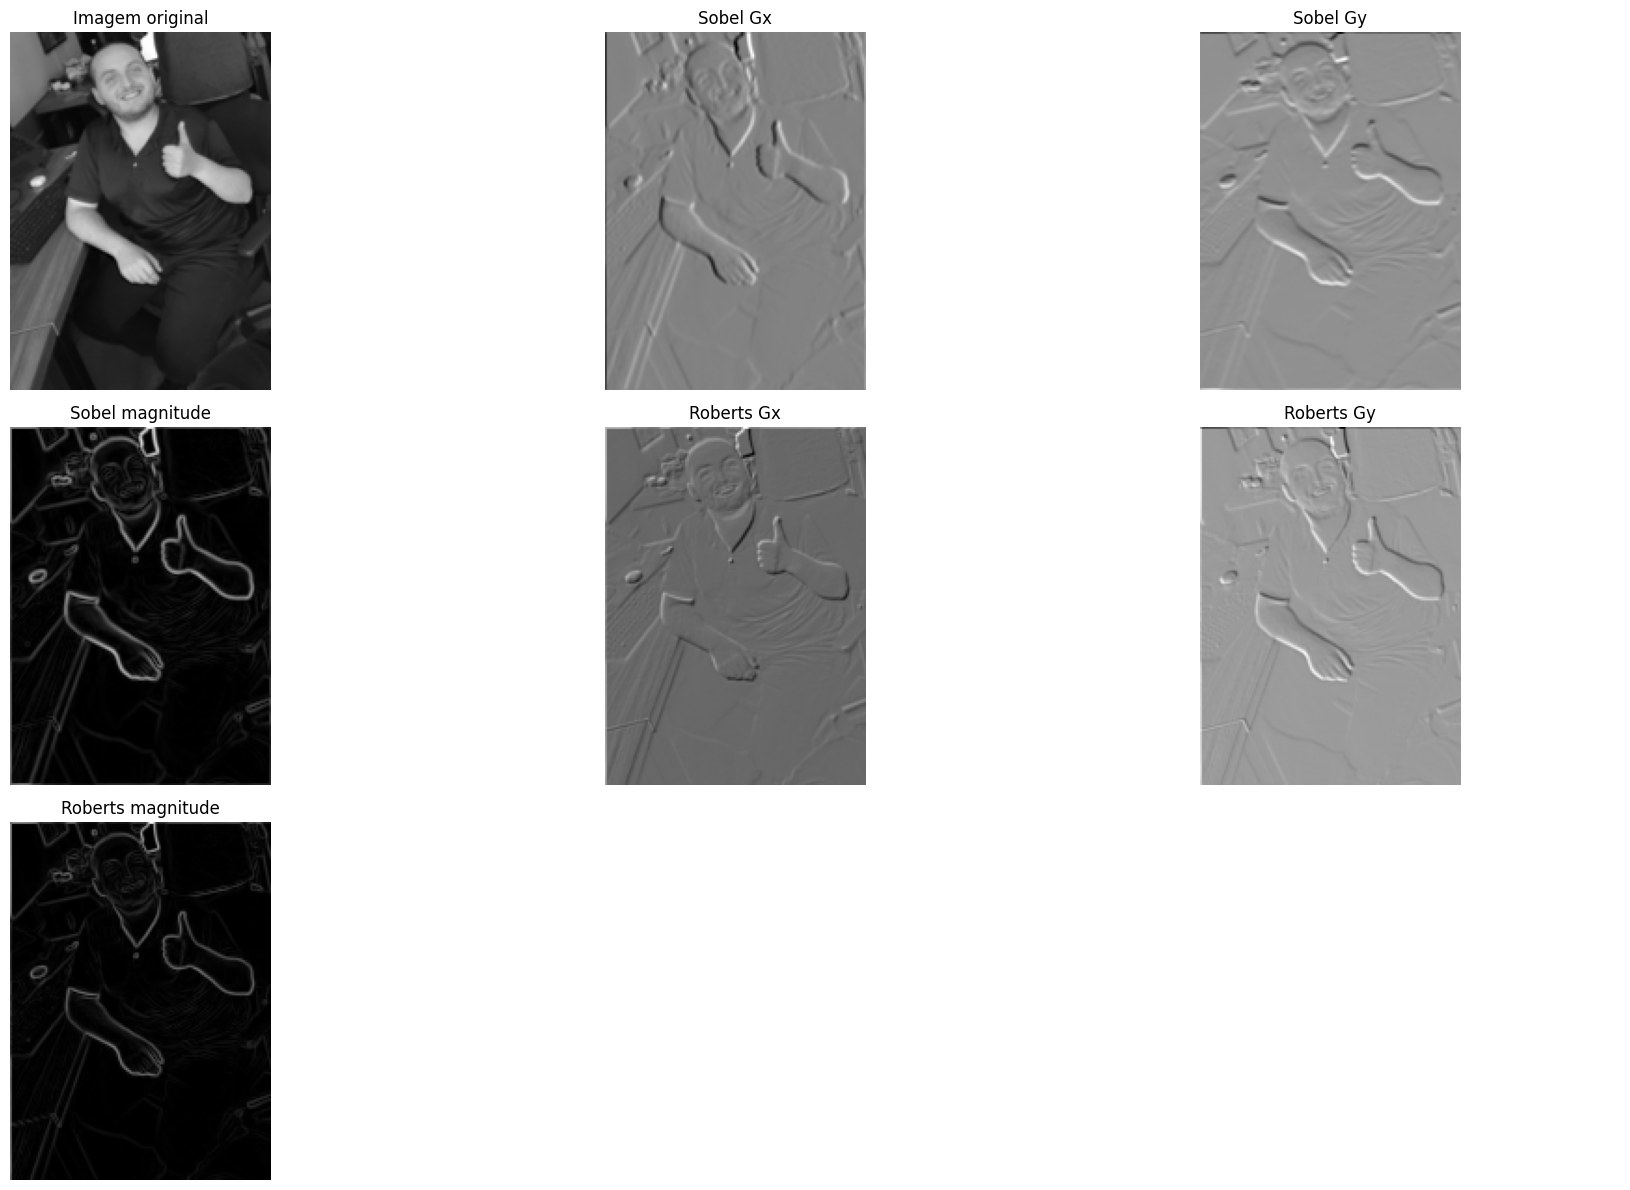

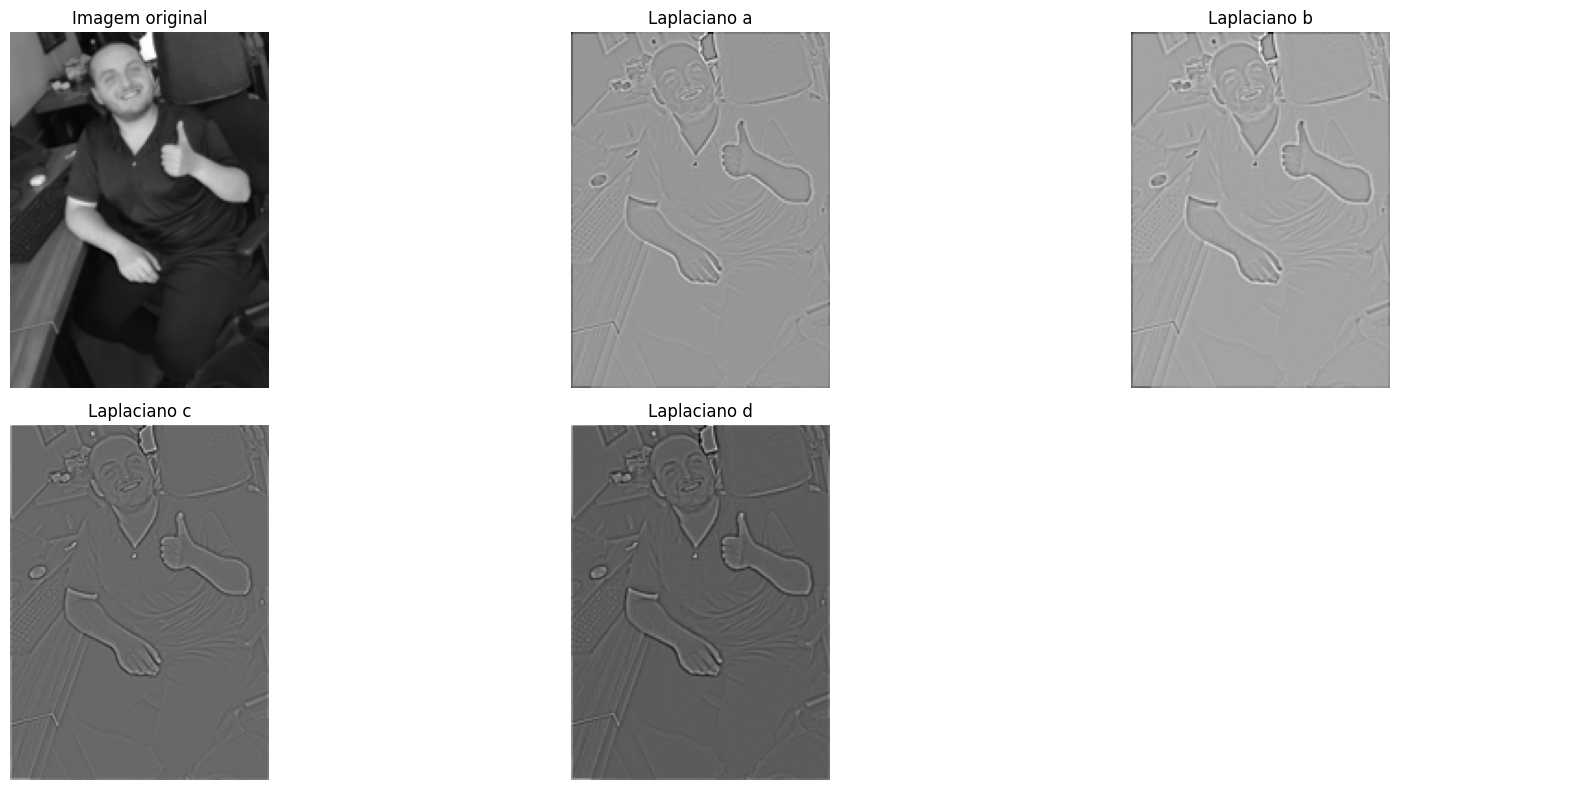

In [ ]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1],
])

roberts_x = np.array([
    [1, 0],
    [0, -1],
])

roberts_y = np.array([
    [0, -1],
    [1, 0],
])

laplacian_kernels = {
    "Laplaciano a": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    "Laplaciano b": np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]]),
    "Laplaciano c": np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]]),
    "Laplaciano d": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
}

sobel_gx = convolve2d_manual(image, sobel_x)
sobel_gy = convolve2d_manual(image, sobel_y)
sobel_mag = gradient_magnitude(sobel_gx, sobel_gy)

roberts_gx = convolve2d_manual(image, roberts_x)
roberts_gy = convolve2d_manual(image, roberts_y)
roberts_mag = gradient_magnitude(roberts_gx, roberts_gy)

laplacian_results = {
    name: convolve2d_manual(image, kernel)
    for name, kernel in laplacian_kernels.items()
}

plot_images_grid(
    [
        ("Imagem original", image),
        ("Sobel Gx", sobel_gx),
        ("Sobel Gy", sobel_gy),
        ("Sobel magnitude", sobel_mag),
        ("Roberts Gx", roberts_gx),
        ("Roberts Gy", roberts_gy),
        ("Roberts magnitude", roberts_mag),
    ],
    ncols=3,
)

plot_images_grid(
    [("Imagem original", image), *laplacian_results.items()],
    ncols=3,
)


### Descricao dos resultados

- **Sobel**: destaca bordas horizontais e verticais. `Gx` responde mais a variacoes na direcao horizontal e `Gy` a variacoes na direcao vertical. A magnitude combina os dois e mostra o contorno geral da imagem.
- **Roberts**: tambem detecta bordas, mas com kernels 2x2. Costuma ser mais sensivel a ruido e destaca melhor mudancas diagonais e transicoes mais bruscas.
- **Laplaciano**: e um operador de segunda derivada. Ele realca regioes com mudanca intensa de intensidade e pode produzir contornos claros e escuros ao redor das bordas.
- **Laplaciano a/c**: usam vizinhanca de 4 conexoes. As duas mascaras sao equivalentes em modulo, mudando apenas o sinal da resposta.
- **Laplaciano b/d**: usam vizinhanca de 8 conexoes. Costumam produzir resposta mais forte porque tambem consideram as diagonais.

Como a convolucao foi implementada manualmente com padding por zeros, pode aparecer um leve artefato escuro nas bordas da imagem filtrada.
